# Sanity and information checks: monthly firm variables

Checks every imported time-series firm variable against the filtered U.S. price universe and against each
other. All functions live in `src/datastream/firm_evaluation.py`; this notebook only configures and displays.
Tables are written to `OUTPUT_DIR` as CSV so results can be compared across downloads.

| Block | Question | Main outputs |
|---|---|---|
| **A Coverage** | For which firms and years is the variable there? | EW/VW coverage of the price universe, coverage by size group, firm-years, history gaps, matching |
| **B Timing** | When and how often does the value change, and does it stop when the stock dies? | changes per firm-year, reporting lag after fiscal year end, stale runs, values after the last price |
| **C Values** | Are the values plausible? | yearly quantiles and means, zeros/negatives, robust-z outliers, unit errors (x1000 in several items at once) |
| **D Consistency** | Do variables agree with each other and with market data? | identities and bounds from `config/firm_relations.csv`, recomputed ratios, alignment of update months |

**Prerequisites:** variables imported with `scripts/03_import_firm_variables.py`, the monthly universe built
with `scripts/05_build_monthly_universe.py`, and (for the reporting lag) the static WC05350 imported.

**Which observations are used.** Coverage, history and padding (A, B3) use all firm-months of a variable.
Timing (B1, B2), levels, distributions and jumps (A4, C) and relations (D1) use only firm-months in which the
stock is in the filtered price universe, so padded values after delisting, pre-listing history and securities
outside the universe (non-common stocks, SPAC units, ...) do not distort them.

The summary flags use the heuristic thresholds in `firm_evaluation.THRESHOLDS`; they mark what to look at,
not what is wrong. Values are checked as downloaded (monthly Datastream series, dates moved to month end).

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from datastream import firm_evaluation as fe
from datastream.preprocessing.firm_data import VARIABLES_SUBDIR, load_variable, read_registry
from datastream.preprocessing.static_data import load_static, static_panel_path

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
fe.set_style()

# ── configuration ───────────────────────────────────────────────────────────────────────────────────
REGION = "US"
FIRM_ROOT = Path(os.environ.get("DS_FIRM_ROOT", "D:/Datastream/Firmcharacteristics_Monthly")) / REGION
PRICE_PATH = Path(os.environ.get("DS_PRICE_PATH", "D:/Datastream/PriceData/US/processed"))
PENNY_PERCENTILE = "0.2"
UNIVERSE_FILE = PRICE_PATH / f"monthly_universe_{PENNY_PERCENTILE}.parquet"
VARIABLES = None                   # None = all imported variable panels, or e.g. ["WC02999", "WC01001"]
FYE_VARIABLE = "WC05350"           # static fiscal-year end (for the reporting lag)
ALIGNMENT_CATEGORIES = ["balance_sheet", "income_statement", "cash_flow"]   # for D2
COVERAGE_YEAR = None               # reference year for coverage in the summary; None = year before the last
                                   # full year (recent values, ESG in particular, are published with a delay)
OUTPUT_DIR = FIRM_ROOT / "Paneldata" / "checks"

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
REGISTRY_FILE = REPO / "config" / "firm_variables.csv"
RELATIONS_FILE = REPO / "config" / "firm_relations.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and run the checks

In [2]:
uni = pd.read_parquet(UNIVERSE_FILE)
print(f"Universe: {len(uni):,} stock-months, {uni['DSCD'].nunique():,} stocks, "
      f"{uni['Date'].min():%Y-%m} to {uni['Date'].max():%Y-%m}")

registry = read_registry(REGISTRY_FILE)
signs = dict(zip(registry["variable"], registry.get("sign", pd.Series("", index=registry.index))))
categories = dict(zip(registry["variable"], registry.get("category", pd.Series("", index=registry.index))))

available = sorted(p.stem for p in (FIRM_ROOT / VARIABLES_SUBDIR).glob("*.parquet"))
variables = [v for v in (VARIABLES or available) if v in available]
print(f"{len(variables)} variables: {variables}")

fye = None
if static_panel_path(FIRM_ROOT, FYE_VARIABLE).exists():
    fye = fe.fye_months(load_static(FIRM_ROOT, FYE_VARIABLE), FYE_VARIABLE)
    print(f"Fiscal-year end available for {len(fye):,} firms")
else:
    print(f"{FYE_VARIABLE} not imported: reporting lag is skipped")

results, skipped = {}, []
for v in variables:
    r = fe.check_variable(load_variable(FIRM_ROOT, v), v, uni, fye, signs.get(v, ""), COVERAGE_YEAR)
    if r is None:
        skipped.append(v)
        continue
    results[v] = r
    print(f"  {v}: done")
if skipped:
    print(f"Skipped (no observations; e.g. leftovers of earlier imports or date-valued series): {skipped}")

unit_candidates = fe.unit_error_candidates({v: r["jumps"] for v, r in results.items()})

Universe: 1,349,605 stock-months, 12,327 stocks, 1993-10 to 2025-12
28 variables: ['DY', 'ENERDP023', 'ENERDP024', 'ENERDP025', 'ENERDP123', 'ENERO132V', 'ENERO52V', 'ENERO55V', 'ENSCORE', 'EPS', 'ESGCCBDSC', 'ESGCCSC', 'PE', 'TRESGS', 'WC01001', 'WC01250', 'WC01751', 'WC02003', 'WC02999', 'WC03051', 'WC03251', 'WC03255', 'WC03501', 'WC04601', 'WC08231', 'WC08301', 'WC08326', 'WC18198']
Fiscal-year end available for 6,358 firms
  DY: done
  ENERDP023: done
  ENERDP024: done
  ENERDP025: done
  ENERDP123: done
  ENERO132V: done
  ENERO52V: done
  ENERO55V: done
  ENSCORE: done
  EPS: done
  ESGCCBDSC: done
  ESGCCSC: done
  PE: done
  TRESGS: done
  WC01001: done
  WC01250: done
  WC01751: done
  WC02003: done
  WC02999: done
  WC03051: done
  WC03251: done
  WC03255: done
  WC03501: done
  WC04601: done
  WC08231: done
  WC08301: done
  WC08326: done
  WC18198: done


## 2. Summary

One row per variable. `flags` lists the checks outside the thresholds below; the sections after this one
show the details behind each number.

In [3]:
summary = fe.add_unit_errors(fe.summary_table([r["summary"] for r in results.values()]), unit_candidates)
summary.insert(0, "category", [categories.get(v, "") for v in summary.index])
print("Thresholds:", fe.THRESHOLDS)
print(f"Coverage reference year: {summary['coverage_ref_year'].iloc[0]}")
display(summary[["category", "n_flags", "flags", "first_date", "n_firms_in_universe", "first_year_vw_cov_50",
                 "ew_coverage_ref", "vw_coverage_ref", "vw_coverage_last_year", "median_changes_per_year",
                 "modal_lag_months", "share_dead_firms_padded", "share_stale_while_trading",
                 "share_sign_violations", "share_extreme", "n_unit_errors"]])

Thresholds: {'vw_coverage_ref_min': 0.8, 'share_after_last_price_max': 0.02, 'share_dead_firms_padded_max': 0.1, 'share_stale_max': 0.05, 'share_sign_violations_max': 0.001, 'share_extreme_max': 0.005, 'unit_errors_per_1000_firms_max': 1.0, 'outside_universe_share_max': 0.5}
Coverage reference year: 2024


,category,n_flags,flags,first_date,n_firms_in_universe,first_year_vw_cov_50,ew_coverage_ref,vw_coverage_ref,vw_coverage_last_year,median_changes_per_year,modal_lag_months,share_dead_firms_padded,share_stale_while_trading,share_sign_violations,share_extreme,n_unit_errors
variable,,,,,,,,,,,,,,,,
DY,market_ratio,3,values after last price; padding after delisti...,1992-12-31,12326,1993,1.0000,1.0000,1.0000,11.0000,11,0.9528,0.0000,0.0000,0.0000,0
ENERDP023,environmental,3,values after last price; padding after delisti...,2001-07-31,1969,2008,0.3884,0.9054,0.4579,1.0000,1,0.2500,0.0006,0.0000,0.0000,0
ENERDP024,environmental,3,values after last price; padding after delisti...,2001-10-31,1917,2009,0.3852,0.9043,0.4575,1.0000,1,0.2526,0.0011,0.0000,0.0000,0
ENERDP025,environmental,3,values after last price; padding after delisti...,2001-02-28,1891,2009,0.3829,0.9039,0.4575,1.0000,1,0.2638,0.0017,0.0000,0.0018,0
ENERDP123,environmental,3,values after last price; padding after delisti...,2001-01-31,4626,2002,0.8229,0.9635,0.1151,1.0000,1,0.1503,0.0004,0.0000,0.0000,0
ENERO132V,environmental,3,values after last price; padding after delisti...,2006-10-31,5239,2015,0.9197,0.9928,0.7870,1.0000,1,0.2658,0.0007,0.0000,0.0000,0
ENERO52V,environmental,3,values after last price; padding after delisti...,2010-02-28,1781,2011,0.3610,0.8598,0.0791,1.0000,1,0.2387,0.0000,0.0000,0.0000,0
ENERO55V,environmental,3,values after last price; padding after delisti...,2010-02-28,1786,2011,0.3625,0.8607,0.0791,1.0000,1,0.2552,0.0000,0.0000,0.0000,0
ENSCORE,esg_score,3,values after last price; padding after delisti...,2001-01-31,3870,2002,0.6807,0.8333,0.0573,1.0000,1,0.1429,0.0003,0.0000,0.0000,0


## A. Coverage
### A1. Coverage of the price universe over time
EW: share of the stocks in the filtered price universe that have a value in that month. VW: their share of
total market cap. A large gap between the two lines means small stocks are missing.

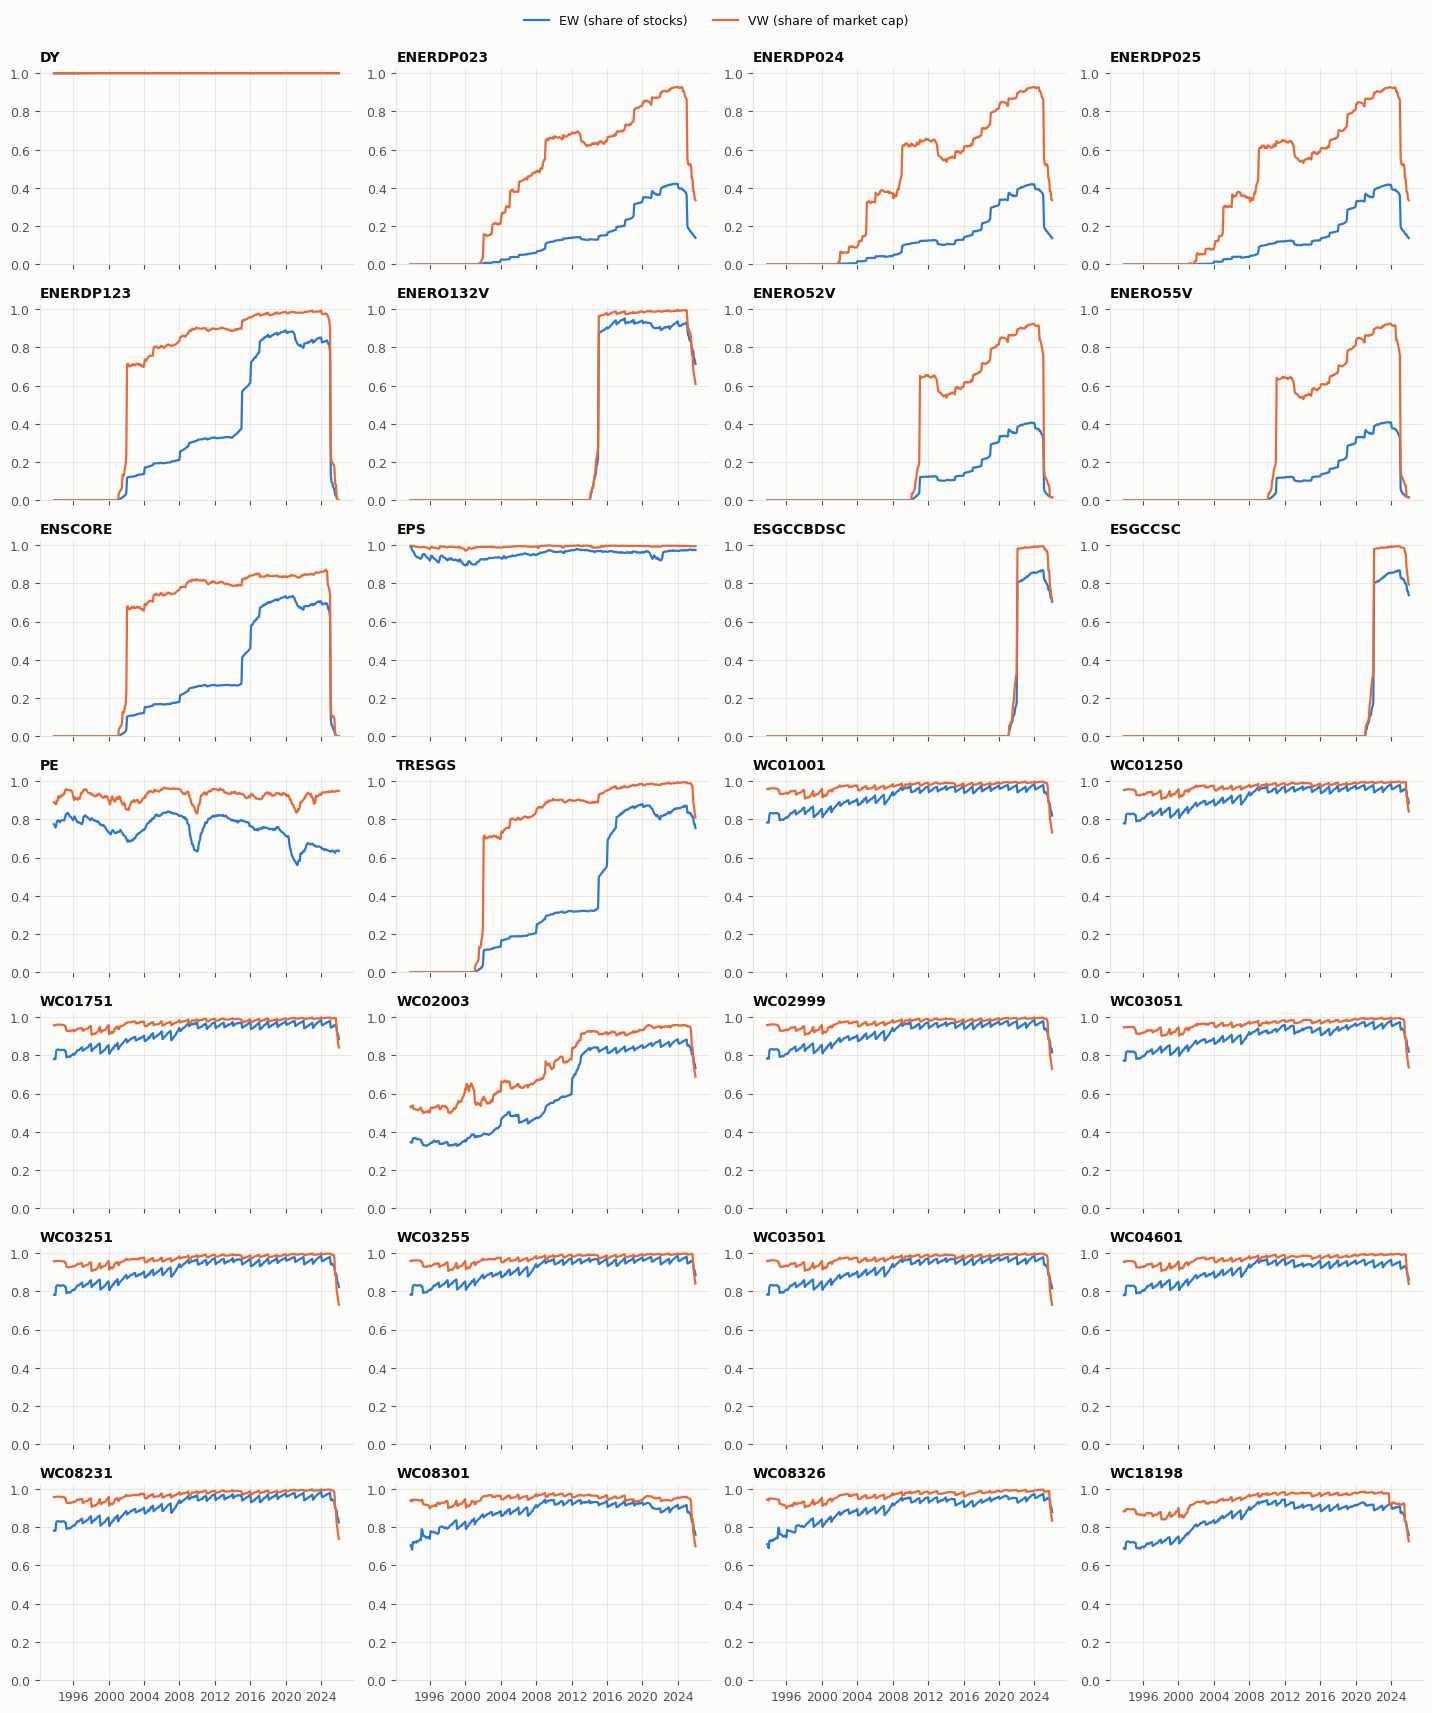

In [4]:
fig = fe.plot_coverage(results)
fig.savefig(OUTPUT_DIR / "A1_coverage.png", dpi=130, bbox_inches="tight")
plt.show()

### A2. Coverage by size group
Average monthly EW coverage per year and size group (Q1 = smallest; NYSE breakpoints when the statics contain
exchange codes). Shows in which years a variable is effectively a large-cap variable.

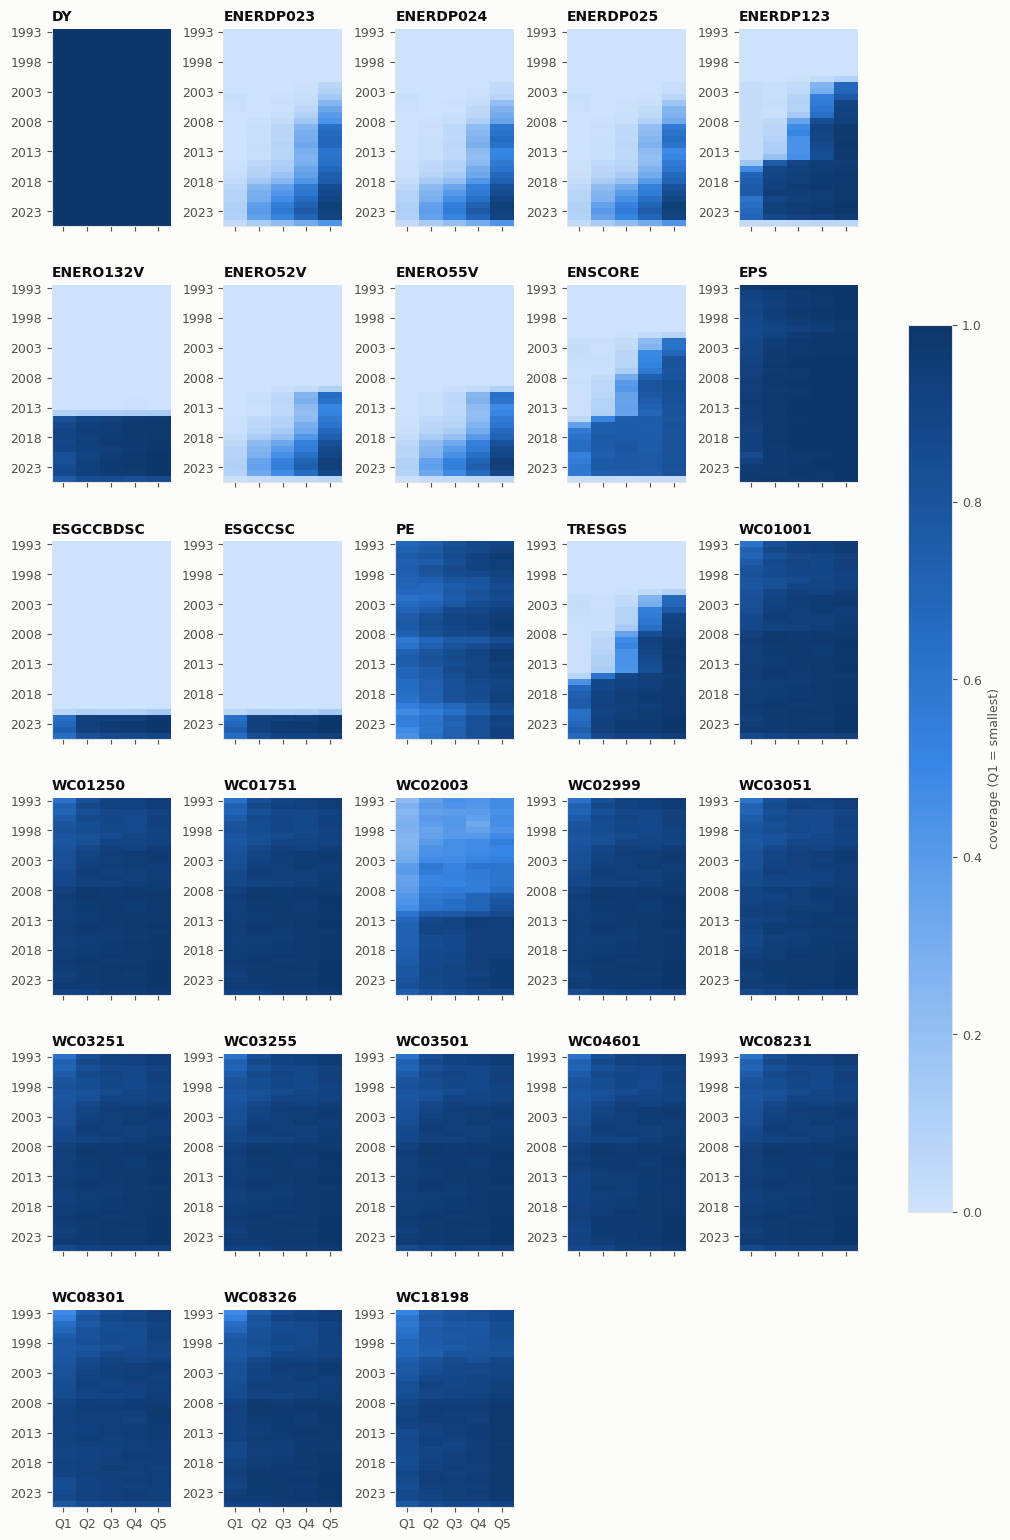

In [5]:
fig = fe.plot_coverage_by_size(results)
fig.savefig(OUTPUT_DIR / "A2_coverage_by_size.png", dpi=130, bbox_inches="tight")
plt.show()

### A3. Firm-years per year and history, matching with the price universe
First table: firms in the price universe with a value, per year. Second table: `n_firms` counts all DSCDs with
a value (also outside the universe), `n_firms_in_universe` those that are ever in the universe with a value.

In [6]:
firms_per_year = pd.DataFrame({v: r["yearly"]["n_firms"] for v, r in results.items() if len(r["yearly"])}).astype("Int64")
display(firms_per_year.T)

cols = ["n_firms", "n_firms_in_universe", "median_history_months", "share_firms_with_gaps", "share_gap_months",
        "share_universe_firms_ever_covered", "share_variable_firms_in_universe", "outside_universe_share"]
display(summary[cols])

Year,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
DY,3450,4038,4676,5058,5187,5143,5164,5025,4583,4327,4142,4103,3982,3920,3868,3611,3490,3418,3326,3273,3303,3373,3414,3385,3340,3348,3380,3585,4033,3997,3986,3957,3949
ENERDP023,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,8,33,82,111,148,192,209,263,377,398,421,435,403,415,485,551,622,781,1032,1152,1336,1497,1499,1408,699
ENERDP024,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,18,57,79,129,164,155,205,340,357,379,388,333,341,412,470,551,730,976,1117,1312,1480,1489,1397,692
ENERDP025,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,11,49,68,109,155,140,190,322,344,368,380,325,334,400,448,528,705,944,1088,1291,1471,1479,1389,692
ENERDP123,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,156,492,519,678,708,705,739,914,981,1003,998,986,996,1181,1926,2395,2695,2785,2865,2981,3027,3150,3128,3082,448
ENERO132V,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2,1,1,3,4,5,6,687,2943,3026,3032,3051,3065,3226,3525,3519,3538,3549,3413
ENERO52V,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,117,377,386,332,341,411,469,547,726,962,1108,1292,1449,1446,1329,210
ENERO55V,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,117,365,377,323,333,398,447,527,704,940,1086,1278,1460,1455,1334,210
ENSCORE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,136,430,459,591,611,603,631,766,817,829,817,805,807,871,1442,1941,2188,2278,2362,2464,2517,2608,2597,2558,306
EPS,3369,3714,4290,4580,4758,4738,4638,4538,4224,4015,3822,3814,3752,3684,3617,3442,3341,3267,3213,3183,3188,3238,3264,3243,3190,3218,3246,3381,3691,3845,3844,3835,3845


,n_firms,n_firms_in_universe,median_history_months,share_firms_with_gaps,share_gap_months,share_universe_firms_ever_covered,share_variable_firms_in_universe,outside_universe_share
variable,,,,,,,,
DY,35555,12326,322.0000,0.0000,0.0000,1.0000,0.3467,0.8248
ENERDP023,3898,1969,72.0000,0.1588,0.0524,0.2179,0.5251,0.5641
ENERDP024,3809,1917,72.0000,0.1777,0.0679,0.2139,0.5211,0.5635
ENERDP025,3780,1891,72.0000,0.1738,0.0664,0.2058,0.5230,0.5611
ENERDP123,8472,4626,96.0000,0.0276,0.0098,0.4916,0.5603,0.5437
ENERO132V,10767,5239,108.0000,0.0553,0.0125,0.6918,0.5002,0.6245
ENERO52V,3555,1781,72.0000,0.1249,0.0484,0.2602,0.5077,0.5533
ENERO55V,3580,1786,72.0000,0.1221,0.0482,0.2610,0.5056,0.5523
ENSCORE,7095,3870,96.0000,0.0061,0.0011,0.4101,0.5572,0.5529


### A4. Levels over time
Median and 1%-trimmed mean of the firm-year values (last value of each firm in each calendar year). A step
in the median that is not visible in the economy points to a change in units, definitions or coverage.

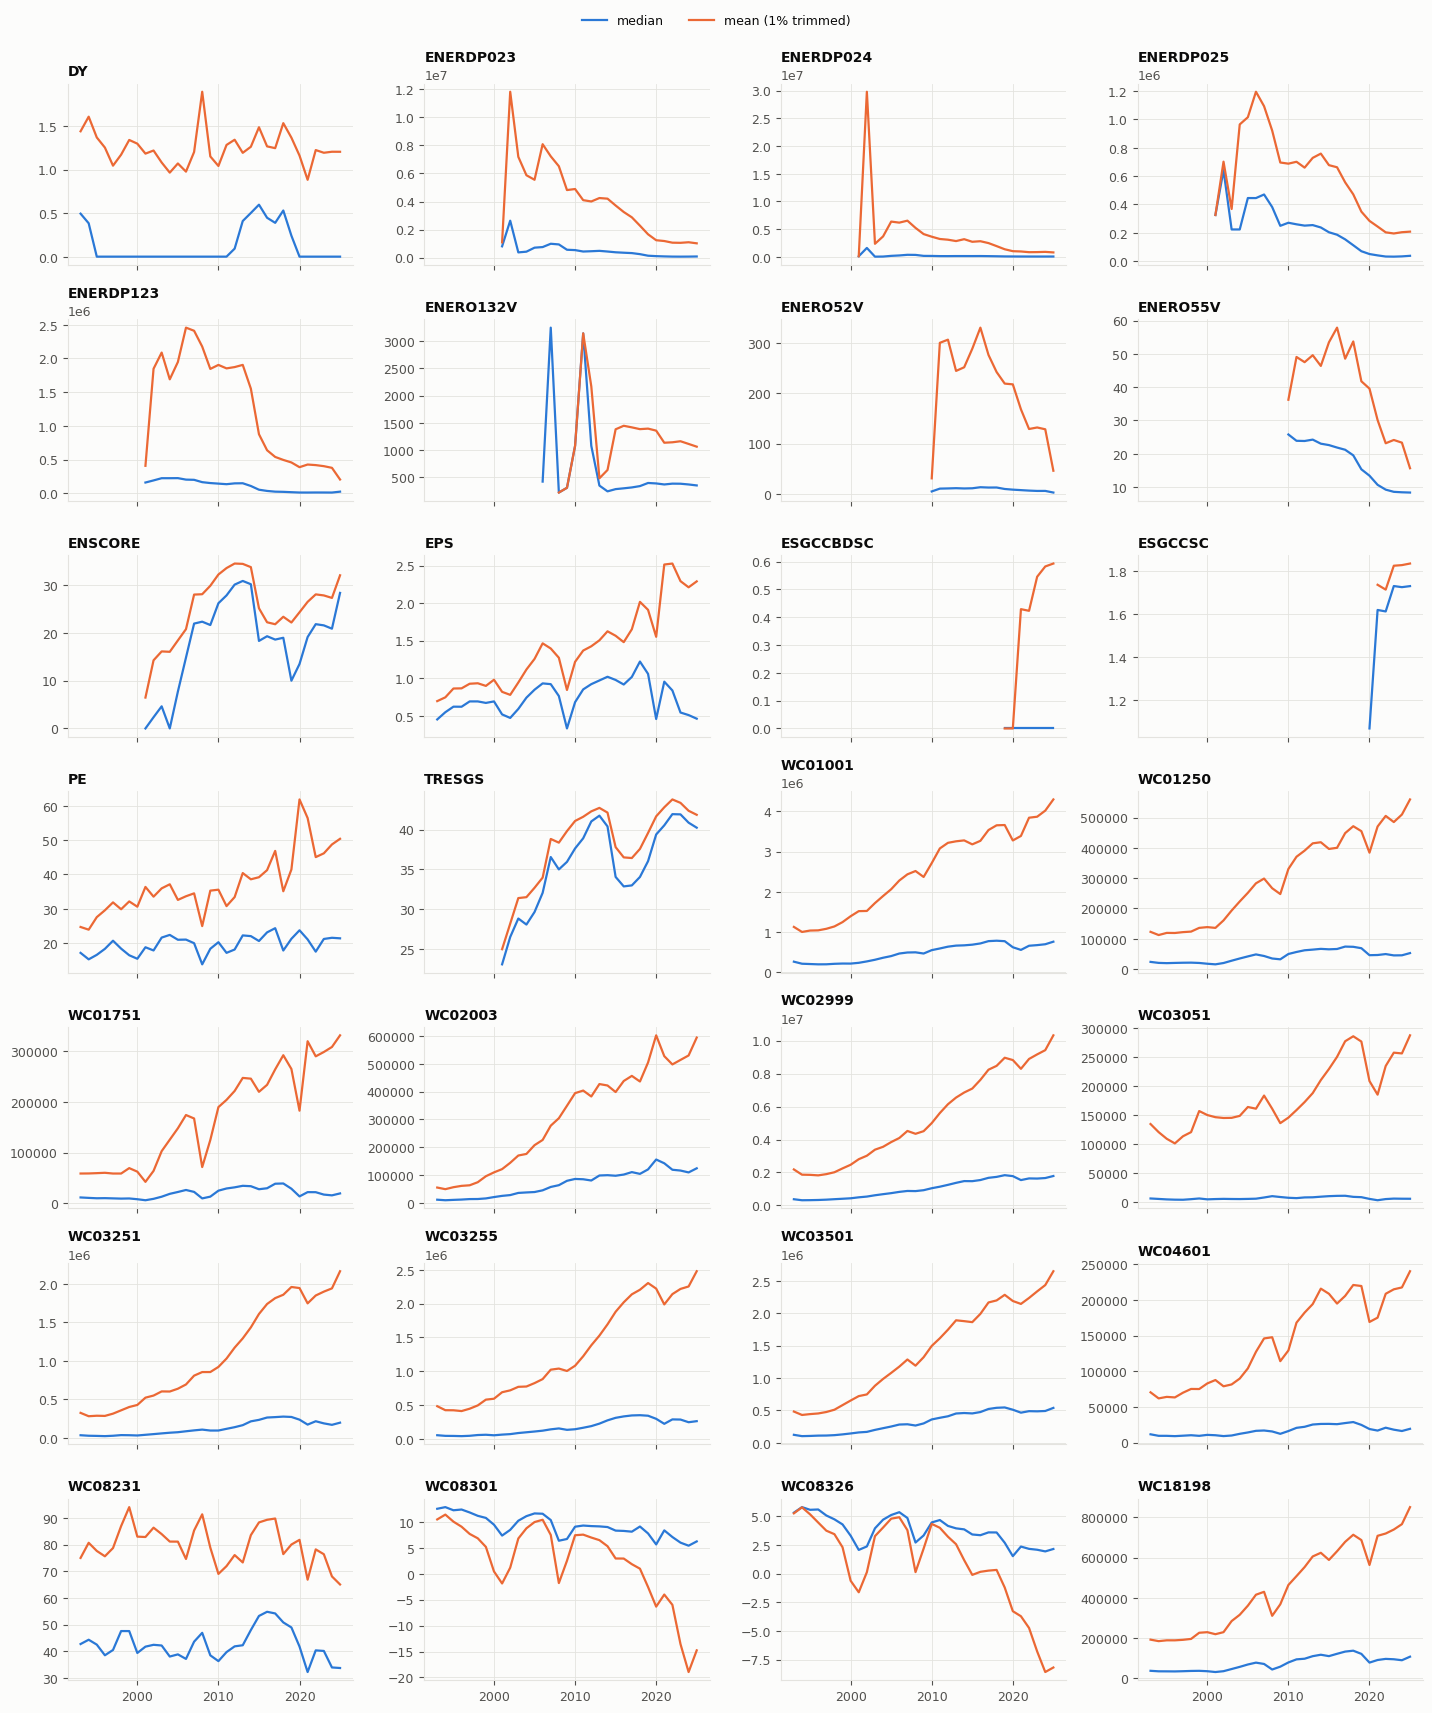

In [7]:
fig = fe.plot_yearly_levels(results)
plt.show()

## B. Timing
### B1. Value changes per firm-year
Firm-years with at least 12 months in the price universe. Annual items should change about once a year, interim
items up to four times. Firm-years with 0 changes are stale data, or a value that is legitimately constant
(e.g. zero debt, no controversies): compare with B3.

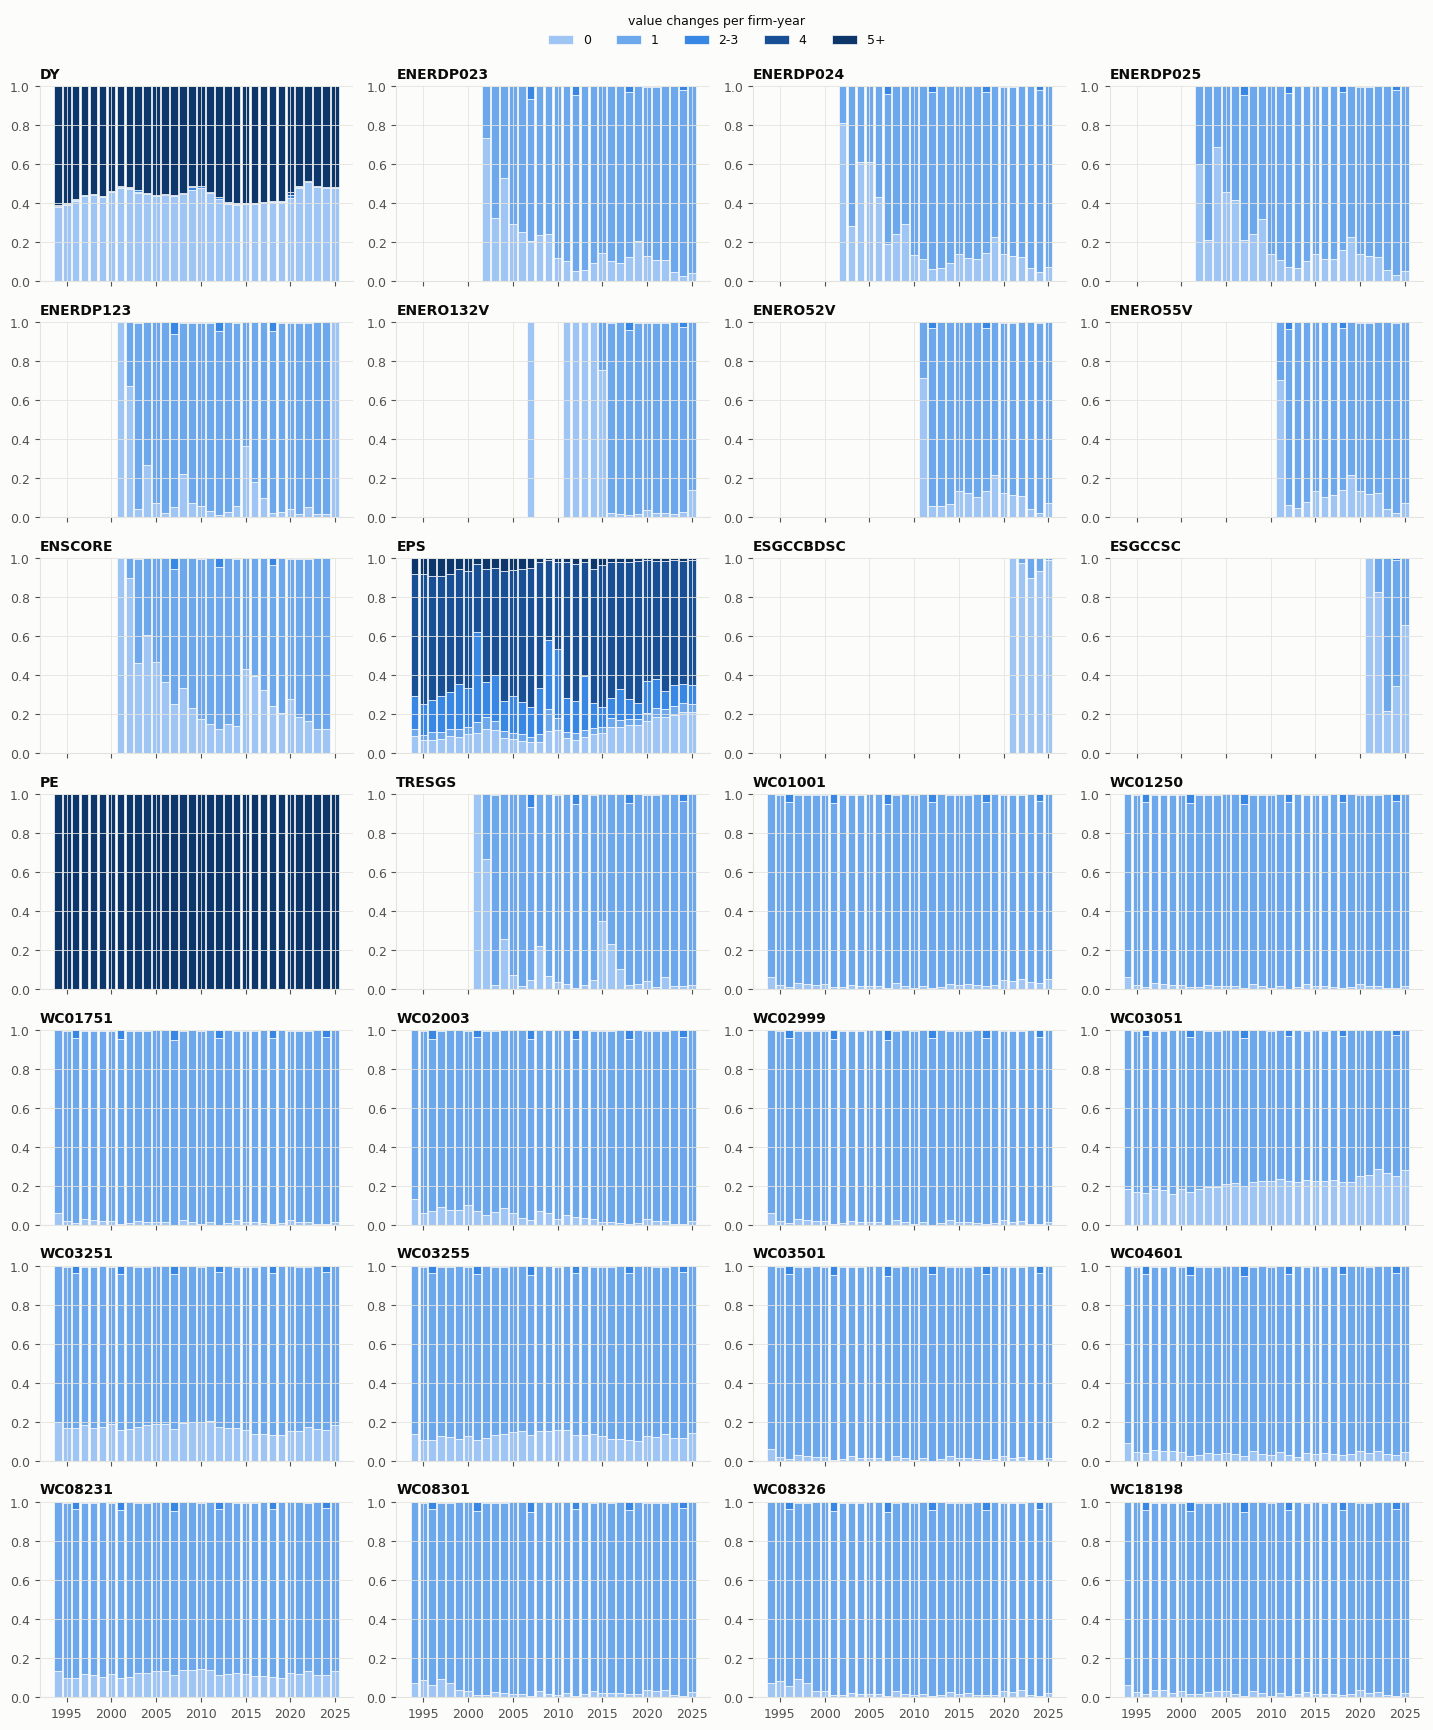

In [8]:
fig = fe.plot_update_frequency(results)
fig.savefig(OUTPUT_DIR / "B1_update_frequency.png", dpi=130, bbox_inches="tight")
plt.show()

### B2. Reporting lag after fiscal year end
Month of each value change relative to the fiscal-year-end month (current WC05350). The mode is the typical
delay between fiscal year end and availability in Datastream, which matters for point-in-time merges.

In [9]:
lag = pd.DataFrame({v: r["lag"]["share"] for v, r in results.items() if len(r["lag"])}).T
if len(lag):
    display(lag.reindex(columns=range(12)).fillna(0).style.format("{:.2f}").background_gradient(axis=1, cmap="Blues"))

months_after_fye,0,1,2,3,4,5,6,7,8,9,10,11
DY,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08,0.08
ENERDP023,0.09,0.89,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENERDP024,0.08,0.89,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENERDP025,0.09,0.89,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENERDP123,0.07,0.88,0.01,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENERO132V,0.06,0.88,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.01
ENERO52V,0.08,0.89,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENERO55V,0.08,0.89,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
ENSCORE,0.08,0.88,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
EPS,0.01,0.06,0.13,0.05,0.11,0.14,0.01,0.11,0.13,0.01,0.11,0.13


### B3. Stale values and values after the last price
* `share_after_last_price`: observations after the stock's last month in the filtered price universe.
* `share_dead_firms_padded`: delisted stocks with values more than 12 months after their last price.
* `share_before_first_price`: observations before the stock's first month in the universe (pre-listing history
  added by the data vendor, or months removed by the price filters).
* `share_stale_while_trading`: share of the universe firm-months whose value is **non-zero** and unchanged for
  more than `STALE_MONTHS` months. `share_zero_runs_while_trading`: the same for runs of zeros, which are usually
  economic (no debt, no dividends, no controversies) and not counted as stale.

Padding and pre-listing values disappear when firm data are merged onto the price universe; the stale share is
what would remain in a merged panel.

In [10]:
display(summary[["share_after_last_price", "share_after_delisting", "share_dead_firms_padded",
                 "share_before_first_price", "share_stale_while_trading", "share_zero_runs_while_trading",
                 "share_firms_with_stale_run", "share_firm_years_no_change"]])

,share_after_last_price,share_after_delisting,share_dead_firms_padded,share_before_first_price,share_stale_while_trading,share_zero_runs_while_trading,share_firms_with_stale_run,share_firm_years_no_change
variable,,,,,,,,
DY,0.5358,0.1456,0.9528,0.0193,0.0000,0.3794,0.0001,0.4391
ENERDP023,0.0701,0.0360,0.2500,0.0189,0.0006,0.0000,0.0023,0.1834
ENERDP024,0.0691,0.0351,0.2526,0.0169,0.0011,0.0061,0.0021,0.2206
ENERDP025,0.0689,0.0353,0.2638,0.0152,0.0017,0.0010,0.0026,0.2061
ENERDP123,0.0497,0.0224,0.1503,0.0420,0.0004,0.0012,0.0021,0.1785
ENERO132V,0.0688,0.0203,0.2658,0.0914,0.0007,0.0000,0.0036,0.3806
ENERO52V,0.0632,0.0324,0.2387,0.0155,0.0000,0.0000,0.0000,0.1408
ENERO55V,0.0626,0.0322,0.2552,0.0142,0.0000,0.0000,0.0000,0.1417
ENSCORE,0.0505,0.0220,0.1429,0.0284,0.0003,0.1233,0.0017,0.3271


## C. Values
### C1. Cross-sectional distribution per year
Bands: p5-p95 and p25-p75 of firm-year values, line: median. Log scale for non-negative variables.

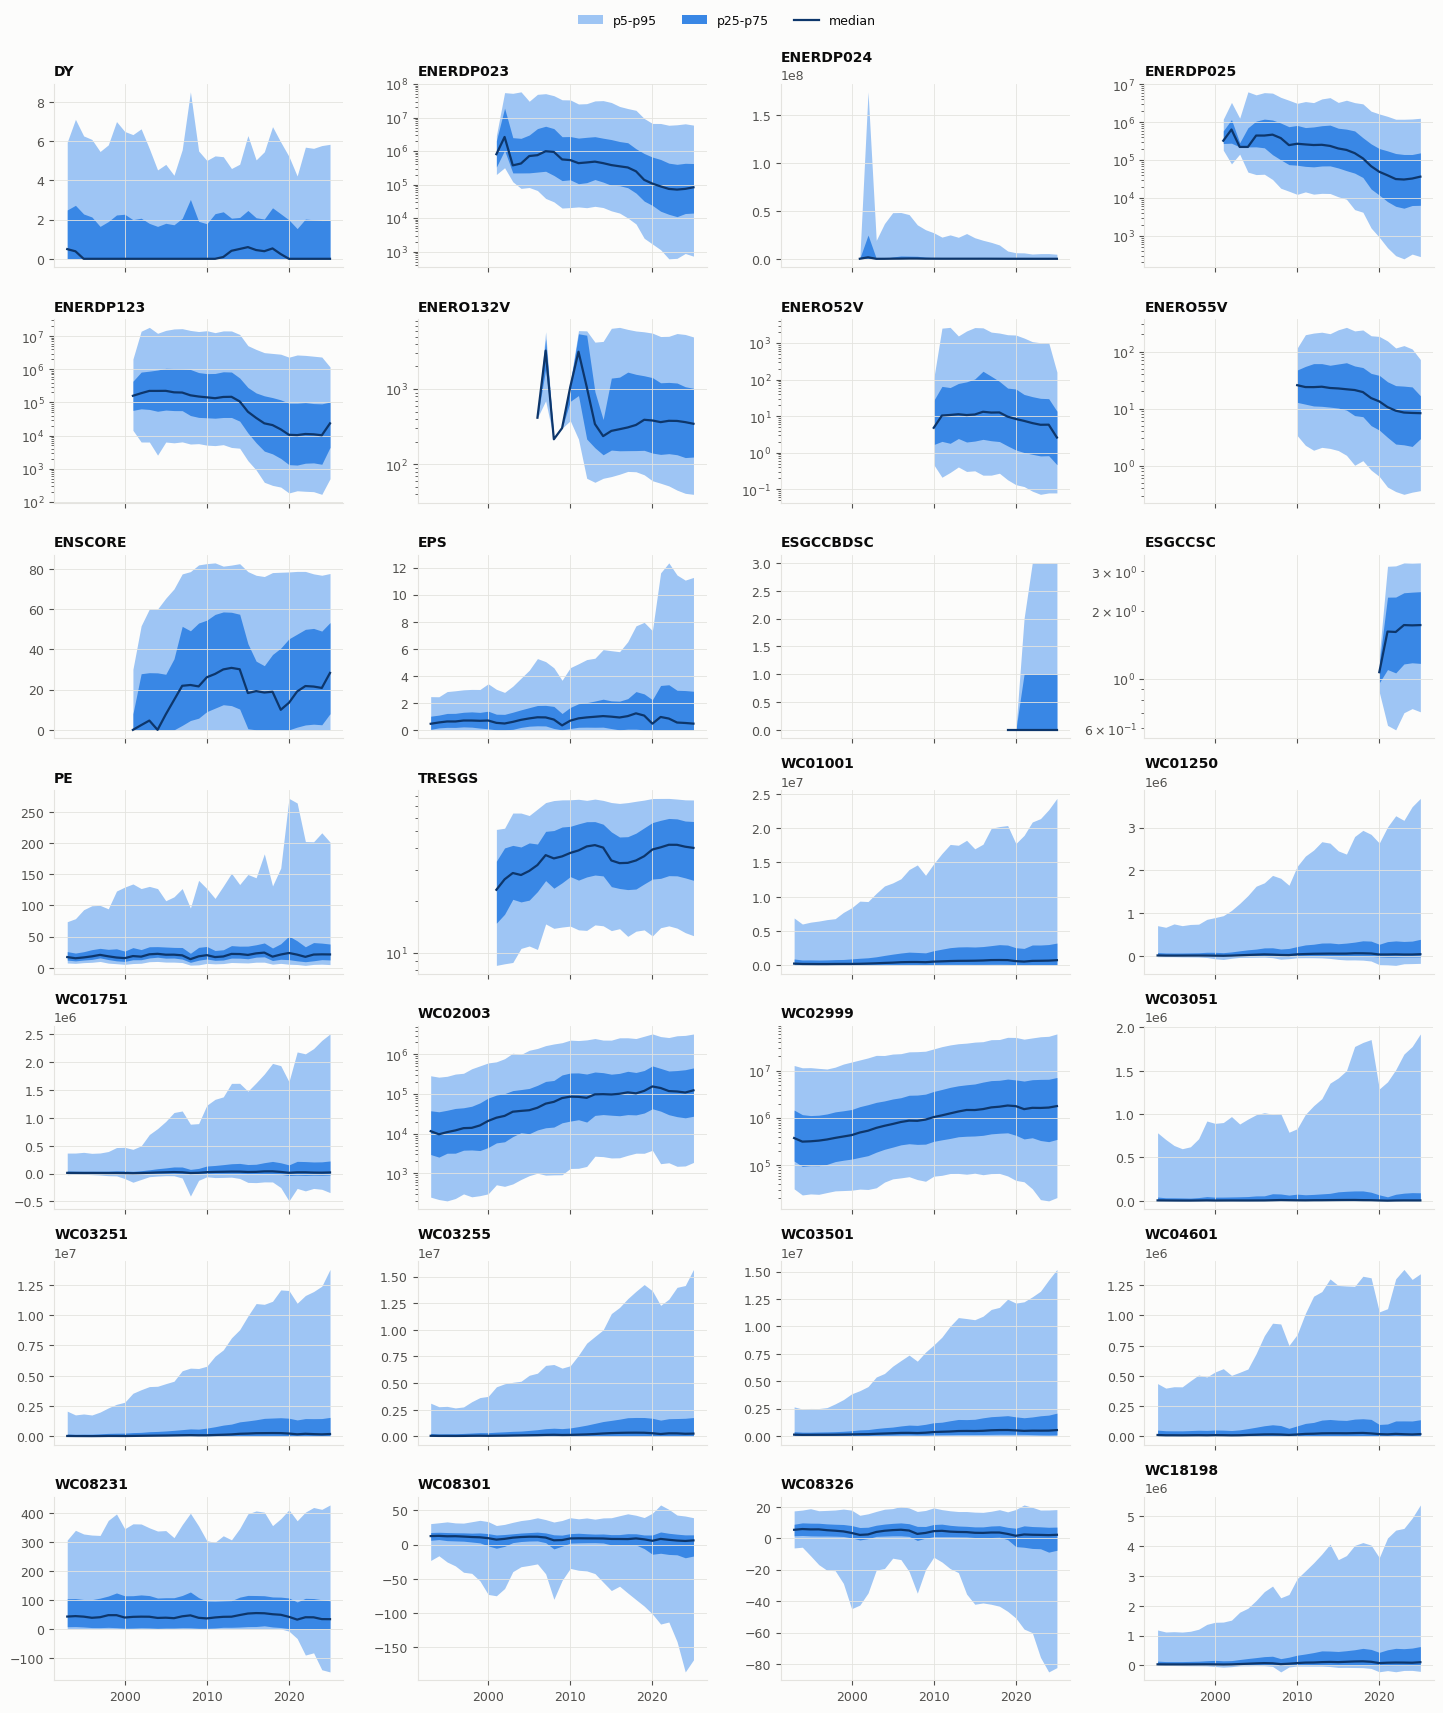

In [11]:
fig = fe.plot_quantiles(results, signs)
fig.savefig(OUTPUT_DIR / "C1_quantiles.png", dpi=130, bbox_inches="tight")
plt.show()

### C2. Zeros, negatives and extreme values
Sign violations are counted for variables marked `nonneg` in the registry. Extreme: |robust z| > `EXTREME_Z`
within the year (median/MAD, on log10 for non-negative variables and on asinh(x / median |x|) otherwise).

In [12]:
display(summary[["share_zero", "share_negative", "share_sign_violations", "share_extreme"]])
extremes = pd.concat({v: r["extremes"] for v, r in results.items() if len(r["extremes"])},
                     names=["variable"]).reset_index(level=0)
extremes.to_csv(OUTPUT_DIR / "C2_extreme_values.csv", index=False)
display(extremes.sort_values("robust_z", key=abs, ascending=False).head(20))

,share_zero,share_negative,share_sign_violations,share_extreme
variable,,,,
DY,0.5379,0.0000,0.0000,0.0000
ENERDP023,0.0008,0.0000,0.0000,0.0000
ENERDP024,0.0201,0.0000,0.0000,0.0000
ENERDP025,0.0057,0.0000,0.0000,0.0018
ENERDP123,0.0036,0.0000,0.0000,0.0000
ENERO132V,0.0000,0.0000,0.0000,0.0000
ENERO52V,0.0003,0.0000,0.0000,0.0000
ENERO55V,0.0000,0.0000,0.0000,0.0000
ENSCORE,0.2452,0.0000,0.0000,0.0000


,variable,DSCD,Year,Date,value,robust_z
8287,ENERDP025,905147,2004,2004-12-31,69.0400,-67.3801
8005,ENERDP025,905039,2004,2004-12-31,"15,800,000.0000",35.5315
10425,ENERDP025,916548,2004,2004-12-31,"13,571,683.0000",34.2637
7149,ENERDP025,901666,2004,2004-12-31,"7,900,000.0000",29.7513
8339,ENERDP025,905271,2004,2004-12-31,"6,985,322.4980",28.7251
8156,ENERDP025,905102,2004,2004-12-31,"5,070,000.0000",26.0527
8821,ENERDP025,905818,2004,2004-12-31,"4,500,000.0000",25.0581
21379,EPS,30122K,2007,2007-12-31,"78,862,640.0000",21.7432
11062,ENERDP025,922726,2004,2004-12-31,"2,540,000.0000",20.2889
21378,EPS,30122K,2006,2006-12-31,"14,358,960.0000",19.9737


### C3. Large jumps and unit errors
For non-negative level variables (registry `sign = nonneg`), within the universe: a change by a factor of at
least ~316 (`jump`), or by at least ~8 that is undone within two years (`reversal`). On their own these are
mostly economic: SPACs (pre-IPO balance sheet to trust account), mergers, and cash or short-term debt moving by
orders of magnitude. A **unit error** scales all items of a firm-year by the same factor, so it is identified
across items: at least `UNIT_ERROR_MIN_VARS` items jump in the same month by (nearly) the same power of 1000.

In [13]:
jump_tables = {v: r["jumps"] for v, r in results.items() if len(r["jumps"])}
if jump_tables:
    jumps = pd.concat(jump_tables, names=["variable"]).reset_index(level=0).reset_index(drop=True)
    jumps.to_csv(OUTPUT_DIR / "C3_large_jumps.csv", index=False)
    print("Large jumps per variable and type:")
    display(jumps.groupby(["variable", "type"]).size().unstack(fill_value=0))
    print("Firm-months with jumps in several items, by year (SPAC waves show up here):")
    multi = unit_candidates.assign(Year=unit_candidates["Date"].dt.year)
    display(multi.groupby(["Year", "unit_error"]).size().unstack(fill_value=0).T)
unit_candidates.to_csv(OUTPUT_DIR / "C3_multi_item_jumps.csv", index=False)
unit_errors = unit_candidates[unit_candidates["unit_error"]]
print(f"Unit error candidates: {len(unit_errors)} firm-months")
display(unit_errors.head(30))

Large jumps per variable and type:


type,jump,reversal
variable,,
DY,0,11
ENERDP023,3,7
ENERDP024,6,8
ENERDP025,7,8
ENERDP123,29,29
ENERO132V,6,15
ENERO52V,4,9
ENERO55V,8,4
ENSCORE,1,7


Firm-months with jumps in several items, by year (SPAC waves show up here):


Year,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
unit_error,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
False,8,6,10,8,10,9,16,13,8,17,16,13,15,18,18,8,6,10,15,11,8,10,9,14,13,14,12,19,23,18,20,14
True,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Unit error candidates: 1 firm-months


,DSCD,Date,n_vars,variables,median_log10,spread,unit_error
0,510385,1999-10-31,3,"WC03051,WC03251,WC03255",2.9936,0.0757,True


## D. Consistency across variables
### D1. Identities, bounds and recomputed ratios
Evaluated on December cross-sections of firm-years in the price universe. `share_ratio_within_5pct` is computed
over firm-years with a non-zero right-hand side; 0 = 0 cases are shown in `share_both_zero`. `compare` rows are
informational: the
definitions differ (e.g. average vs. year-end equity), so look at the median ratio and rank correlation.
The `mtbv` row also checks units: MV is in millions, Worldscope items are assumed to be in thousands.
Relations with variables that are not imported yet are skipped.

In [14]:
relations = fe.read_relations(RELATIONS_FILE)
needed = sorted(set().union(*[fe._names(e) for e in relations[["lhs", "rhs", "condition"]].to_numpy().ravel()]))
dec = fe.december_panel(FIRM_ROOT, [v for v in needed if v in available], uni)
rel_table, rel_by_year, rel_examples = fe.evaluate_relations(dec, relations)
rel_table.to_csv(OUTPUT_DIR / "D1_relations.csv", index=False)
display(rel_table[["relation", "kind", "status", "n_firm_years", "share_violations", "median_ratio",
                   "share_ratio_within_5pct", "share_both_zero", "spearman", "condition", "note"]])

,relation,kind,status,n_firm_years,share_violations,median_ratio,share_ratio_within_5pct,share_both_zero,spearman,condition,note
0,total_debt_identity,identity,ok,103747,0.0008,1.0000,0.9994,0.1370,1.0000,,total debt = short-term + long-term debt
1,debt_le_assets,le,ok,105494,0.0062,0.1688,NaN,0.0000,0.8319,,
2,cash_le_assets,le,ok,67369,0.0000,0.0768,NaN,0.0000,0.7257,,
3,capex_le_assets,le,ok,104534,0.0000,0.0251,NaN,0.0000,0.6595,,
4,st_debt_le_total_debt,le,ok,103829,0.0000,0.1085,NaN,0.1371,0.7148,,
5,lt_debt_le_total_debt,le,ok,105461,0.0002,0.8959,NaN,0.1386,0.9672,,
6,ebitda_margin,range,ok,93960,0.0125,NaN,NaN,NaN,NaN,WC01001 >= 10000,EBITDA / sales outside [-200%; 100%] for firms...
7,debt_to_equity,compare,ok,105405,NaN,1.0000,0.9994,0.1385,1.0000,,Datastream ratio vs recomputation
8,roe,compare,ok,100399,NaN,1.0400,0.4014,0.0000,0.9475,,Worldscope uses average equity: only roughly e...
9,roa,compare,ok,102514,NaN,1.1565,0.1226,0.0000,0.9615,,Worldscope adds back after-tax interest and us...


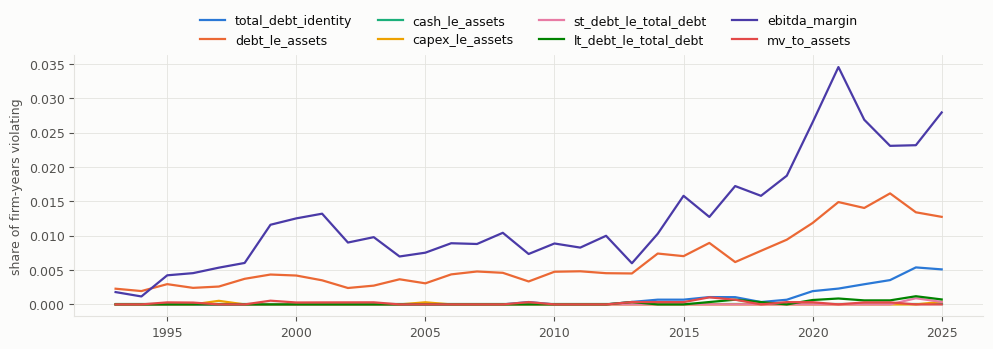

In [15]:
if len(rel_by_year.columns):
    fig = fe.plot_relation_violations(rel_by_year)
    fig.savefig(OUTPUT_DIR / "D1_violations_by_year.png", dpi=130, bbox_inches="tight")
    plt.show()
for name, ex in rel_examples.items():
    ex.to_csv(OUTPUT_DIR / f"D1_examples_{name}.csv", index=False)

### D2. Alignment of update months
For each pair of accounting variables: share of firm-years (both with exactly one change) in which the value
changes in the same month. Items from the same annual report should be close to 1; low values mean the
series are stamped differently, which matters when variables are combined into ratios.

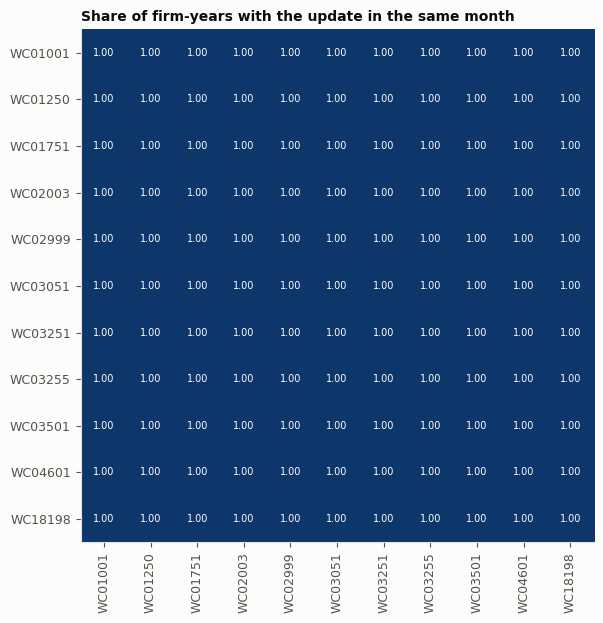

In [16]:
align_vars = [v for v in variables if categories.get(v, "") in ALIGNMENT_CATEGORIES]
if len(align_vars) >= 2:
    alignment = fe.update_alignment({v: results[v]["panel_universe"] for v in align_vars})
    alignment.to_csv(OUTPUT_DIR / "D2_update_alignment.csv")
    fig = fe.plot_matrix(alignment, "Share of firm-years with the update in the same month")
    fig.savefig(OUTPUT_DIR / "D2_update_alignment.png", dpi=130, bbox_inches="tight")
    plt.show()

## 3. Save tables

In [17]:
summary.to_csv(OUTPUT_DIR / "summary.csv")
firms_per_year.to_csv(OUTPUT_DIR / "A3_firms_per_year.csv")
pd.concat({v: r["coverage"] for v, r in results.items()}, names=["variable"]).to_csv(OUTPUT_DIR / "A1_coverage.csv")
pd.concat({v: r["coverage_by_size"] for v, r in results.items() if len(r["coverage_by_size"])},
          names=["variable"]).to_csv(OUTPUT_DIR / "A2_coverage_by_size.csv")
for name, key in [("A4_yearly", "yearly"), ("B1_updates", "updates"), ("C1_quantiles", "quantiles")]:
    tabs = {v: r[key] for v, r in results.items() if len(r[key])}
    if tabs:
        pd.concat(tabs, names=["variable"]).to_csv(OUTPUT_DIR / f"{name}.csv")
if len(lag):
    lag.to_csv(OUTPUT_DIR / "B2_reporting_lag.csv")
print(f"Tables and figures written to {OUTPUT_DIR}")

Tables and figures written to D:\Datastream\Firmcharacteristics_Monthly\US\Paneldata\checks
